# Байесовский подход в анализе данных
## Задание 3

**Правила:**

* Дедлайны см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Выполненную работу нужно отправить телеграм-боту. Для начала работы с ботом каждый раз отправляйте `/start`. Дождитесь подтверждения от бота, что он принял файл. Если подтверждения нет, то что-то не так. **Работы, присланные иным способом, не принимаются.**
* Дедлайны см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Прислать нужно **ноутбук в формате `ipynb`**.
* Следите за размером файлов. **Бот не может принимать файлы весом более 20 Мб.** Если файл получается больше, заранее разделите его на несколько.
* Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания все участники списывания получат штраф.**
* Решения, размещенные на каких-либо интернет-ресурсах, не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Для выполнения задания используйте этот ноутбук в качестве основы, ничего не удаляя из него. Можно добавлять необходимое количество ячеек.
* Комментарии к решению пишите в markdown-ячейках.
* Выполнение задания (ход решения, выводы и пр.) должно быть осуществлено на русском языке.
* Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/"><img src="https://miptstats.github.io/theta_grader_small.png" style="display: inline; vertical-align: middle;"></a> **ThetaGrader**. Результат проверки валидируется и исправляется человеком, после чего комментарии отправляются студентам.
* Если код будет не понятен проверяющему, оценка может быть снижена.
* Никакой код из данного задания при проверке запускаться не будет. *Если код студента не выполнен, недописан и т.д., то он не оценивается.*
* В каждой задаче не забывайте делать **пояснения и выводы**.
* **Код из рассказанных на занятиях ноутбуков** можно использовать без ограничений.


**Правила оформления теоретических задач:**

* Решения необходимо прислать одним из следующих способов:
  * фотографией в правильной ориентации, где все четко видно, а почерк разборчив,
    * отправив ее как файл боту вместе с ноутбуком *или*
    * вставив ее в ноутбук посредством `Edit -> Insert Image` (<font color="red">фото, вставленные ссылкой, не принимаются</font>);
  * в виде $LaTeX$ в markdown-ячейках.
* Решения не проверяются, если какое-то требование не выполнено. Особенно внимательно все проверьте в случае выбора второго пункта (вставки фото в ноутбук). <font color="red"><b>Неправильно вставленные фотографии могут не передаться при отправке.</b></font> Для проверки попробуйте переместить `ipynb` в другую папку и открыть его там.
* В решениях поясняйте, чем вы пользуетесь, хотя бы кратко. Например, если пользуетесь независимостью, то достаточно подписи вида "*X и Y незав.*"
* Решение, в котором есть только ответ, и отсутствуют вычисления, оценивается в 0 баллов.

**Баллы за задание:**

* Задача 1 &mdash;  30 баллов
* Задача 2 &mdash;  30 баллов
* Задача 3 &mdash;  50 баллов
* Задача 4 &mdash;  будет добавлена.

In [26]:
# Bot check

# HW_ID: ds_bayes3
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: not final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

__________________
### Задача 1.

Пусть $X_1, ..., X_n$ &mdash; выборка распределения Пуассона, завышенного в нуле (zero-inflated Poisson distribution), имеющего плотность
$$p_{\varepsilon\lambda}(x) = \begin{cases}
\varepsilon + (1-\varepsilon) e^{-\lambda}, &x=0; \\ (1-\varepsilon) \frac{\lambda^x e^{-\lambda}}{x!}, & x \geqslant 1.
\end{cases}$$
Иначе говоря, рассматривается смесь пуассоновского распределения с нулём.


Предложите процедуру поиска оценки максимального правдоподобия параметра $\theta = (\varepsilon, \lambda)$ с помощью EM-алгоритма.
Распишите ELBO.
Выпишите также итоговую процедуру.

$\square$

## СМ. ПДФ

$\blacksquare$

__________________
### Задача 2.

Пусть $X_1, ..., X_n \sim \mathcal{N}(a, \Sigma)$, причём часть значений пропущена. Все пропуски имеют случайный характер и не зависят от значений элементов выборки. Оценить параметры и восстановить значения можно с помощью EM-алгоритма. На занятии расписан E-шаг и часть M-шага.
* Доведите до конца M-шаг. 
* Распишите ELBO.

Выпишите также итоговую процедуру.

$\square$
## СМ. ПДФ
$\blacksquare$

__________________
### Задача 3.



In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as sps
from itertools import combinations
import matplotlib.patches as mpatches
import seaborn as sns
import numba

from sklearn.mixture import GaussianMixture

Cкачайте данные <a href="http://archive.ics.uci.edu/ml/datasets/wine">wine dataset</a> и выберите столбцы `Alcohol`, `Ash`, `Total phenols`, `Proanthocyanins`.

In [28]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
wine = fetch_ucirepo(id=109) 
  
# data (as pandas dataframes) 
X = wine.data.features 
y = wine.data.targets 

In [29]:
X_selected = X[['Alcohol', 'Ash', 'Total_phenols', 'Proanthocyanins']]
y_labels = y.values.flatten() 

dataset = pd.concat([X_selected, y], axis=1)
dataset.head()

,Alcohol,Ash,Total_phenols,Proanthocyanins,class
0,14.23,2.43,2.80,2.29,1
1,13.20,2.14,2.65,1.28,1
2,13.16,2.67,2.80,2.81,1
3,14.37,2.50,3.85,2.18,1
4,13.24,2.87,2.80,1.82,1


**1.** В данных указан тип вина. Предположим, что данные в выбранных столбцах образуют смесь из трёх нормальных распределений по типу вина. Оцените параметры смеси с помощью `sklearn.mixture.GaussianMixture`. Визуализируйте полученный результат. Насколько хорошее разбиение на кластеры получилось?

In [30]:
gmm = GaussianMixture(n_components=3).fit(X_selected)
gmm_labels = gmm.predict(X_selected)

In [31]:
distributions = [
    sps.multivariate_normal(mean=gmm.means_[i], cov=gmm.covariances_[i]) for i in range(3)
]

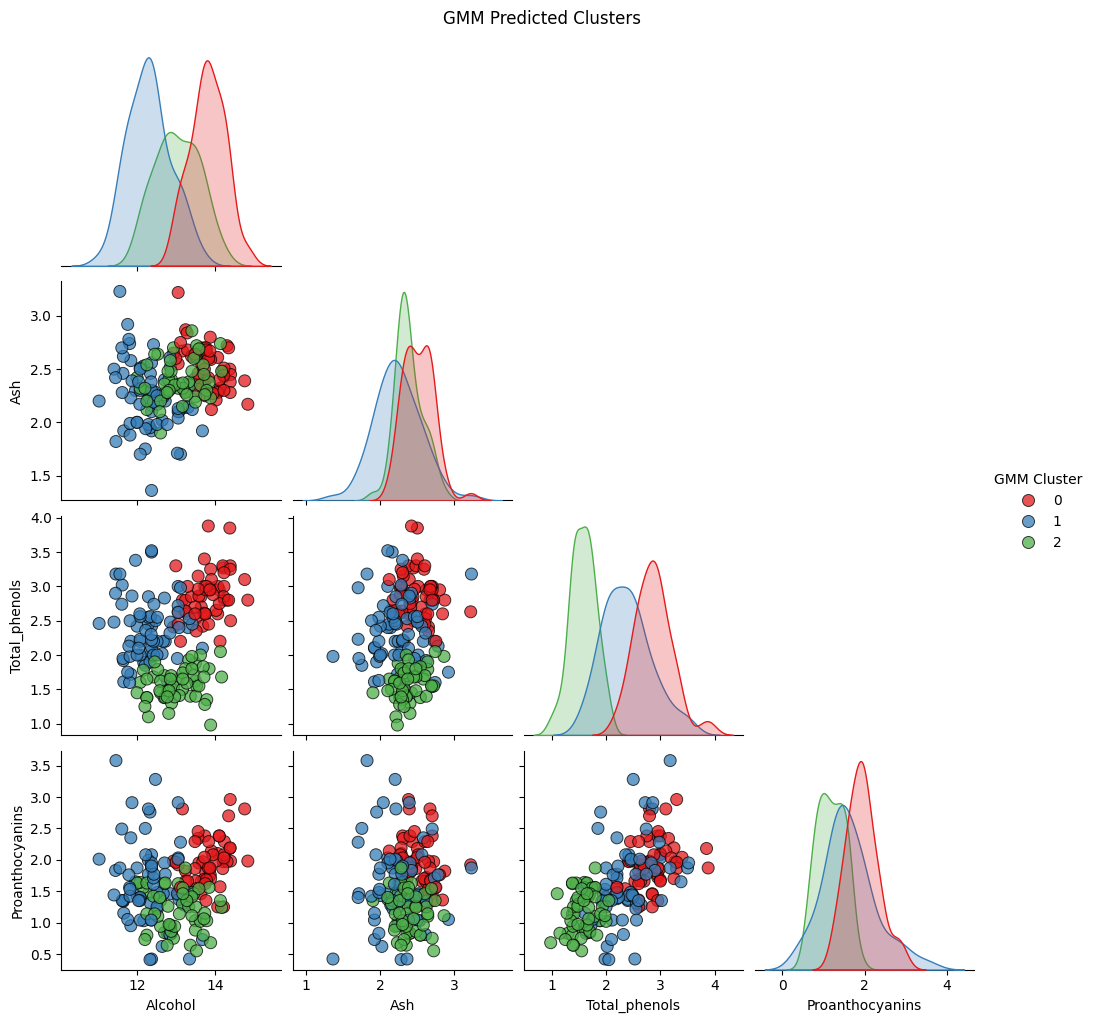

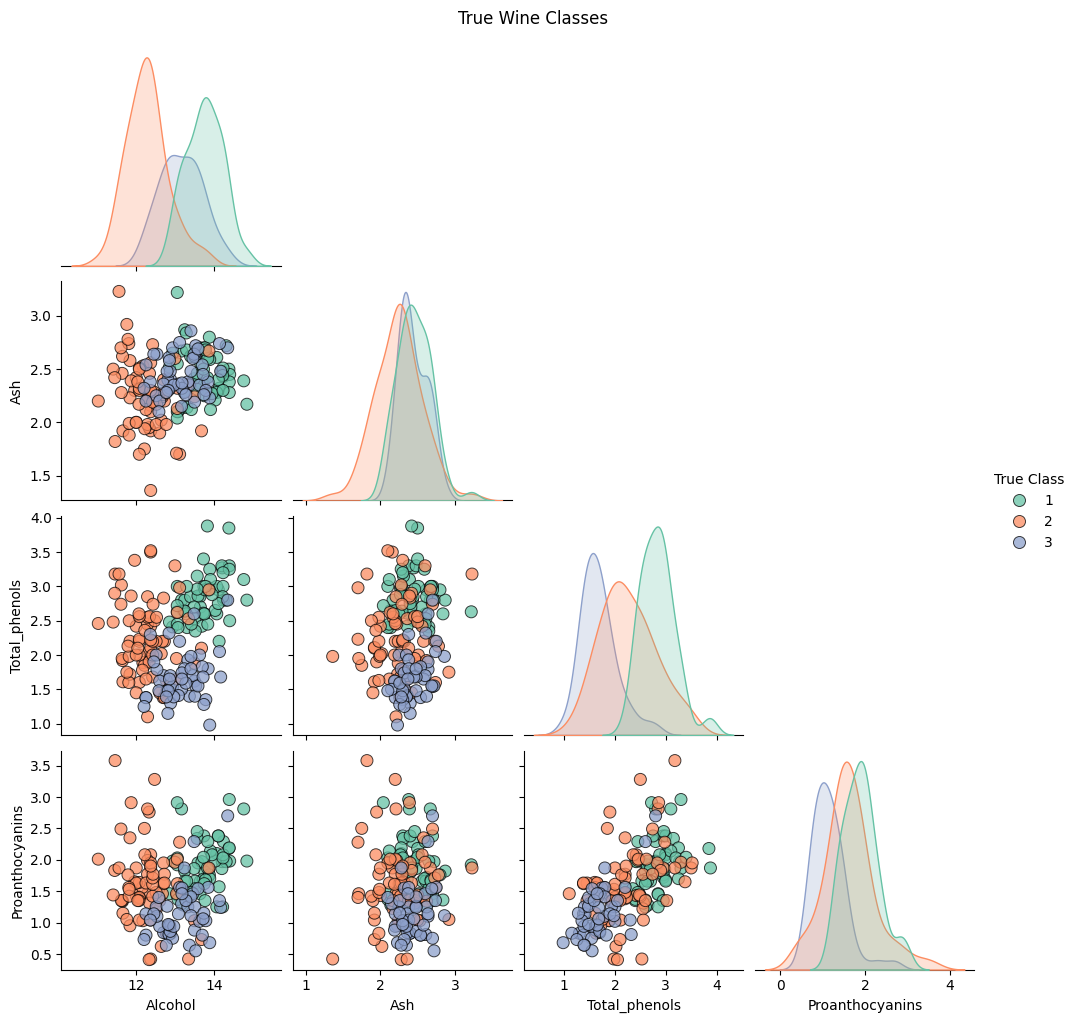

In [32]:
# Добавляем метки в DataFrame
df_gmm = X_selected.copy()
df_gmm['GMM Cluster'] = gmm_labels.astype(str)  # чтобы цвета различались как категории

df_true = X_selected.copy()
df_true['True Class'] = y_labels.astype(str)

# === Pairplot для GMM кластеров ===
sns.pairplot(df_gmm, hue='GMM Cluster', palette='Set1', diag_kind='kde', plot_kws={'s':75, 'alpha':0.75, 'edgecolor':'k'}, corner=True)
plt.suptitle('GMM Predicted Clusters', y=1.02)
plt.show()

# === Pairplot для истинных классов ===
sns.pairplot(df_true, hue='True Class', palette='Set2', diag_kind='kde', plot_kws={'s':75, 'alpha':0.75, 'edgecolor':'k'}, corner=True)
plt.suptitle('True Wine Classes', y=1.02)
plt.show()

Визуально, GMM справился достаточно неплохо, он смог повторить очертания истинных кластеров.

**2.** Удалите из данных 10% случайных значений. Предполагая нормальность данных в каждом классе с помощью EM-алгоритма оцените параметры и пропущенные значения, считая метки класса известными. Визуализируйте значения ELBO в зависимости от номера итерации. Насколько качественно восстановлены значения?

При реализации может пригодиться библиотека `numba`.

Удалим 10% значений в данных

In [33]:
dataset_missing = dataset.copy()
feature_cols = X_selected.columns.tolist()

n_rows, n_features = dataset_missing[feature_cols].shape
n_missing = int(0.1 * n_rows * n_features)

row_indices = np.random.randint(0, n_rows, size=n_missing)
col_indices = np.random.randint(0, n_features, size=n_missing)

for row, col in zip(row_indices, col_indices):
    dataset_missing.iat[row, col] = np.nan

dataset_missing.head(10)

,Alcohol,Ash,Total_phenols,Proanthocyanins,class
0,14.23,2.43,2.80,2.29,1
1,13.20,2.14,2.65,1.28,1
2,13.16,NaN,NaN,2.81,1
3,14.37,2.50,3.85,2.18,1
4,13.24,2.87,2.80,1.82,1
5,14.20,2.45,3.27,1.97,1
6,14.39,2.45,2.50,1.98,1
7,14.06,2.61,2.60,1.25,1
8,14.83,2.17,2.80,1.98,1
9,NaN,NaN,2.98,1.85,1


In [34]:
X_true = dataset[feature_cols].copy()  # это "ground truth"
X_miss = dataset_missing[feature_cols].copy()
y_miss = dataset_missing['class']

In [35]:
class RestoreMissingValues:
    def __init__(self, X, y):
        self.X = X
        self.y = y
        self.n, self.d = self.X.shape
        self.n_classes = np.unique(y).shape[0]

        self.X_k = self.X.notna()
        self.X_u = self.X.isna()

        self.a = np.nanmean(self.X, axis=0)
        self.Sigma = np.nan_to_num(np.cov(self.X.T, bias=True))
        self.Lambda = np.linalg.inv(self.Sigma + 1e-6 * np.eye(self.d))

        self.history = []

    def E_step(self):
        X_hat = self.X.copy().to_numpy()

        m_list = []
        S_list = []
        distributions = []
        for i in range(self.n):
            mask_k = self.X_k.iloc[i].to_numpy()
            mask_u = ~mask_k

            if mask_k.sum() == self.d:  # нет пропусков
                m_list.append(np.zeros(0))
                S_list.append(np.zeros((0, 0)))
                continue

            x_k = X_hat[i, mask_k]
            x_u = X_hat[i, mask_u]

            a_k = self.a[mask_k]
            a_u = self.a[mask_u]

            Sigma_kk = self.Sigma[np.ix_(mask_k, mask_k)]
            Sigma_ku = self.Sigma[np.ix_(mask_k, mask_u)]
            Sigma_uk = self.Sigma[np.ix_(mask_u, mask_k)]
            Sigma_uu = self.Sigma[np.ix_(mask_u, mask_u)]

            Lambda_kk = self.Lambda[np.ix_(mask_k, mask_k)]
            Lambda_ku = self.Lambda[np.ix_(mask_k, mask_u)]
            Lambda_uk = self.Lambda[np.ix_(mask_u, mask_k)]
            Lambda_uu = self.Lambda[np.ix_(mask_u, mask_u)]

            x_k = X_hat[i, mask_k]
            x_u = X_hat[i, mask_u]

            Lambda_uu_inv = np.linalg.inv(Lambda_uu)
            m_i = a_u - Lambda_uu_inv @ Lambda_uk @ (x_k - a_k)
            S_i = Lambda_uu_inv

            X_hat[i, mask_u] = m_i

            m_list.append(m_i)
            S_list.append(S_i)

        self.m_list = m_list
        self.S_list = S_list

        return X_hat, m_list, S_list

    def M_step(self):
        X_hat = self.X.copy().to_numpy()

        a = np.zeros(self.d)
        for i in range(self.n):
            mask_k = self.X_k.iloc[i].to_numpy()
            mask_u = ~mask_k
            x_k = X_hat[i, mask_k]
            m_i = self.m_list[i]
            hat_x = np.concatenate((x_k, m_i), axis=0) if len(m_i) > 0 else x_k
            a += hat_x / self.n

        Sigma = np.zeros((self.d, self.d))
        for i in range(self.n):
            mask_k = self.X_k.iloc[i].to_numpy()
            mask_u = ~mask_k
            x_k = X_hat[i, mask_k]
            m_i = self.m_list[i]
            hat_x = np.concatenate((x_k, m_i), axis=0) if len(m_i) > 0 else x_k

            hat_S_i = np.zeros((self.d, self.d))
            if len(m_i) > 0:
                hat_S_i[np.ix_(mask_u, mask_u)] = self.S_list[i]

            Sigma += ((hat_x - a) @ (hat_x - a).T + hat_S_i) / self.n

        self.a = a
        self.Sigma = Sigma
        self.Lambda = np.linalg.inv(Sigma + 1e-6 * np.eye(self.d))

        return self.a, self.Sigma

    def ELBO(self):
        Lq = 0
        X_np = self.X.to_numpy()

        for i in range(self.n):
            mask_k = self.X_k.iloc[i].to_numpy()
            mask_u = ~mask_k

            x_k = X_np[i, mask_k]
            m_i = self.m_list[i]
            hat_x = np.concatenate((x_k, m_i)) if len(m_i) > 0 else x_k

            hat_S_i = np.zeros((self.d, self.d))
            if len(m_i) > 0:
                hat_S_i[np.ix_(mask_u, mask_u)] = self.S_list[i]

            log_det_Sigma = np.log(np.linalg.det(self.Sigma))
            mahalanobis = (hat_x - self.a).T @ self.Lambda @ (hat_x - self.a)
            trace_term = np.trace(self.Lambda @ hat_S_i)
            if len(m_i) > 0:
                log_det_S_i = np.log(np.linalg.det(self.S_list[i]))
            else:
                log_det_S_i = 0.0

            Lq += log_det_Sigma + mahalanobis + trace_term - log_det_S_i

        Lq *= -0.5
        return Lq

    def fit(self, max_iter=100, tol=1e-6):
        for it in range(max_iter):
            old_a, old_Sigma = self.a.copy(), self.Sigma.copy()
            self.E_step()
            self.M_step()
            elbo = self.ELBO()
            self.history.append(elbo)

            if (
                np.linalg.norm(self.a - old_a) < tol
                and np.linalg.norm(self.Sigma - old_Sigma) < tol
            ):
                print(f"Сошлось на итерации {it+1}")
                break
        return self.a, self.Sigma

    def predict(self, X_new):
        if hasattr(X_new, "to_numpy"):
            X_new = X_new.to_numpy()

        n_new, d = X_new.shape
        assert d == self.d, f"Ожидалась размерность {self.d}, получена {d}"

        X_filled = X_new.copy()

        for i in range(n_new):
            x = X_new[i]
            mask_k = ~np.isnan(x)
            mask_u = np.isnan(x)

            if not np.any(mask_u):
                continue

            idx_k = np.where(mask_k)[0]
            idx_u = np.where(mask_u)[0]

            x_k = x[mask_k]

            a_k = self.a[idx_k]
            a_u = self.a[idx_u]

            Lambda_kk = self.Lambda[np.ix_(idx_k, idx_k)]
            Lambda_ku = self.Lambda[np.ix_(idx_k, idx_u)]
            Lambda_uk = self.Lambda[np.ix_(idx_u, idx_k)]
            Lambda_uu = self.Lambda[np.ix_(idx_u, idx_u)]

            try:
                Lambda_uu_inv = np.linalg.inv(Lambda_uu)
                m_u = a_u - Lambda_uu_inv @ Lambda_uk @ (x_k - a_k)
            except np.linalg.LinAlgError:
                m_u = a_u

            X_filled[i, mask_u] = m_u
        return X_filled
    
    def plot_elbo(self, figsize=(10, 5), title="ELBO по итерациям EM-алгоритма"):
        if len(self.history) == 0:
            print("Нет данных для построения графика. Запустите fit() сначала.")
            return

        import matplotlib.pyplot as plt

        plt.figure(figsize=figsize)
        plt.plot(range(1, len(self.history) + 1), self.history, marker='o', linestyle='-', color='b')
        plt.title(title, fontsize=14)
        plt.xlabel("Итерация", fontsize=12)
        plt.ylabel("ELBO", fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

In [36]:
our_EM = RestoreMissingValues(X_miss, y_miss)
our_EM.fit()

Сошлось на итерации 8


(array([12.18140449,  2.35910112,  2.39530261,  2.38949615]),
 array([[17.36917747, 17.36917735, 17.36917734, 17.36917735],
        [17.36917735, 17.36917746, 17.36917735, 17.36917734],
        [17.36917734, 17.36917735, 17.36917754, 17.36917734],
        [17.36917735, 17.36917734, 17.36917734, 17.36917749]]))

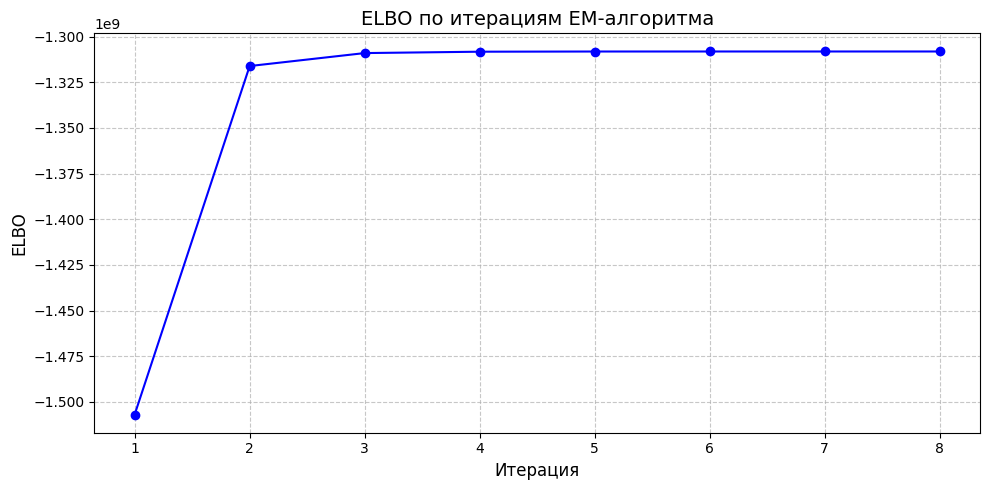

In [37]:
our_EM.plot_elbo()

In [38]:
model = RestoreMissingValues(X_miss, y_miss)
model.fit(max_iter=100, tol=1e-6)

X_filled = model.predict(X_miss)
X_filled_df = pd.DataFrame(X_filled, columns=feature_cols, index=X_miss.index)

Сошлось на итерации 8


In [46]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

metrics = []

for col in feature_cols:
    missing_mask = X_miss[col].isna()
    n_missing = missing_mask.sum()
    if n_missing == 0:
        continue

    pct_missing = (n_missing / len(X_miss)) * 100

    true_val = X_true.loc[missing_mask, col]
    pred_val = X_filled_df.loc[missing_mask, col]

    mae = mean_absolute_error(true_val, pred_val)
    rmse = np.sqrt(mean_squared_error(true_val, pred_val))

    if np.any(true_val == 0):
        mape = float('nan')
    else:
        mape = np.mean(np.abs((true_val - pred_val) / true_val)) * 100

    metrics.append({
        'Feature': col,
        'N_missing': n_missing,
        '% Missing': f"{pct_missing:.2f}%",
        'MAE': mae,
        'RMSE': rmse,
        'MAPE (%)': mape
    })

metrics_df = pd.DataFrame(metrics)

metrics_df['MAE'] = metrics_df['MAE'].round(6)
metrics_df['RMSE'] = metrics_df['RMSE'].round(6)
metrics_df['MAPE (%)'] = metrics_df['MAPE (%)'].apply(
    lambda x: f"{x:.2f}%" if not np.isnan(x) else "N/A (zero true val)"
)

print("Метрики восстановления по столбцам (только на пропущенных позициях):")
display(metrics_df)

Метрики восстановления по столбцам (только на пропущенных позициях):


,Feature,N_missing,% Missing,MAE,RMSE,MAPE (%)
0,Alcohol,14,7.87%,0.836507,1.069828,6.30%
1,Ash,13,7.30%,0.381647,0.465210,17.25%
2,Total_phenols,22,12.36%,0.383906,0.490565,22.19%
3,Proanthocyanins,17,9.55%,1.098938,1.191868,85.43%


**3.** Предложите способ оценки параметров смеси нормальных распределений, если в данных есть пропуски. Выводить формулы и писать реализацию не требуется.

Самыми простыми способами является заполнение пропусков средним или медианой. Также можно ввести функцию похожести, и по оставшимся признакам найти строку, в которой данный признак не пропущен, и заполнить пропуск им. 

Также для замены пропусков можно в целом обучить нейронную сеть по оставшимся признакам, и заполнить пропуски при помощи нее.

**Выводы**

Мы написали свой EM алгоритм, на основе выведенных формул. Как и ожидалось значение ELBO не убывает.

Метрики восстановления также получились достаточно хорошими, что говорит о жизнеспособности данного метода.

__________________
### Задача 4.

Будет добавлена.

---
© 2025 команда <a href="https://thetahat.ru/">ThetaHat</a> для DS-потока